# Домашнее задание 2 (25 баллов)

## Задача 1. Спекральная нормализация (15 баллов)

[Спектральная нормализация](https://arxiv.org/abs/1802.05957) — один из популярных видов нормализации в нейросетях, который особенно часто применяется в генеративно-состязательных сетях.
В PyTorch спектральная нормализация реализована в виде функции [spectral_norm](https://pytorch.org/docs/stable/generated/torch.nn.utils.spectral_norm.html).
Эта функция модифицирует нейросеть, и в нужный слой сети добавляется:
- Вычисление оценки спектральной нормы (наибольшего сингулярного числа) матрицы с помощью степенного метода,
- Нормировка параметра линейного слоя с помощью этой оценки

Задание:
1. (5 баллов) Аналитически найдите константу Липшица для функции умножения матрицы на вектор, где матрица есть результат применения спектральной нормализации, если старшее сингулярное число вычислено точно.
2. (10 баллов) По умолчанию спектральная нормализация в PyTorch делает одну итерацию степенного метода. Достаточно ли этого?
    1. Возьмите в качестве примера последний слой архитектуры ResNet-50, обученной на ImageNet (`resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)`, из [torchvision](https://pytorch.org/vision/main/models.html). Код получения `weight_matrix` приведён в ячейке ниже.
    2. Реализуйте алгоритм вычисления старшего сингулярного значения на основе степенного метода.
    3. Сгенерируйте много различных начальных приближений и оцените среднее и разброс результатов степенного метода.
    4. Изобразите среднее и дисперсии для разного количества шагов в виде [ящиков с усами](https://ru.wikipedia.org/wiki/%D0%AF%D1%89%D0%B8%D0%BA_%D1%81_%D1%83%D1%81%D0%B0%D0%BC%D0%B8).
    5. Проанализируйте результаты, используя теорию сходимости степенного метода.

1. Определение константы Липшица для функции умножения нормированной матрицы на вектор:
    $$ \| \frac{\mathbf{A}}{\sigma_{max} (\mathbf{A})} \mathbf{x_1} - \frac{\mathbf{A}}{\sigma_{max} (\mathbf{A})} \mathbf{x_1} \| \leq L \| \mathbf{x_1}  - \mathbf{x_2} \| $$
    Для второй нормы принимает вид:
    $$ L \geq \frac{\| \frac{\mathbf{A}}{\sigma_{max} (\mathbf{A})} (\mathbf{x_1} - \mathbf{x_2}) \|_2}{\| \mathbf{x_1} - \mathbf{x_2} \|_2} $$
    Подставим максимальное возможное значение в правую часть, чтобы получить равенство:
    $$ L = \sup_{\mathbf{x_1} - \mathbf{x_2} \neq 0} \left( \frac{\| \frac{\mathbf{A}}{\sigma_{max} (\mathbf{A})} (\mathbf{x_1} - \mathbf{x_2}) \|_2}{\| \mathbf{x_1} - \mathbf{x_2} \|_2} \right) = 1 $$
    По определению нормы матрицы.

In [1]:
from typing import List
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from torchvision.models import resnet50, ResNet50_Weights

model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
weight_matrix = model.fc.weight.data.numpy()

In [2]:
def power_iteration(mat: np.ndarray, n_iter: int = 1) -> float:
    if mat.shape[0] > mat.shape[1]:
        mat_sq = mat.T @ mat
    else:
        mat_sq = mat @ mat.T
    eigvec = np.random.randn(mat_sq.shape[1])

    for _ in range(n_iter):
        eigvec = mat_sq @ eigvec
        eigvec /= np.linalg.norm(eigvec)

    return float(np.sqrt(eigvec @ mat_sq @ eigvec))


n_iters = [1, 3, 5, 10, 25, 50]


eigenvalues = {}
for i, n_iter in enumerate(n_iters):
    eigenvalues[n_iter] = [power_iteration(weight_matrix, n_iter) for _ in range(100)]

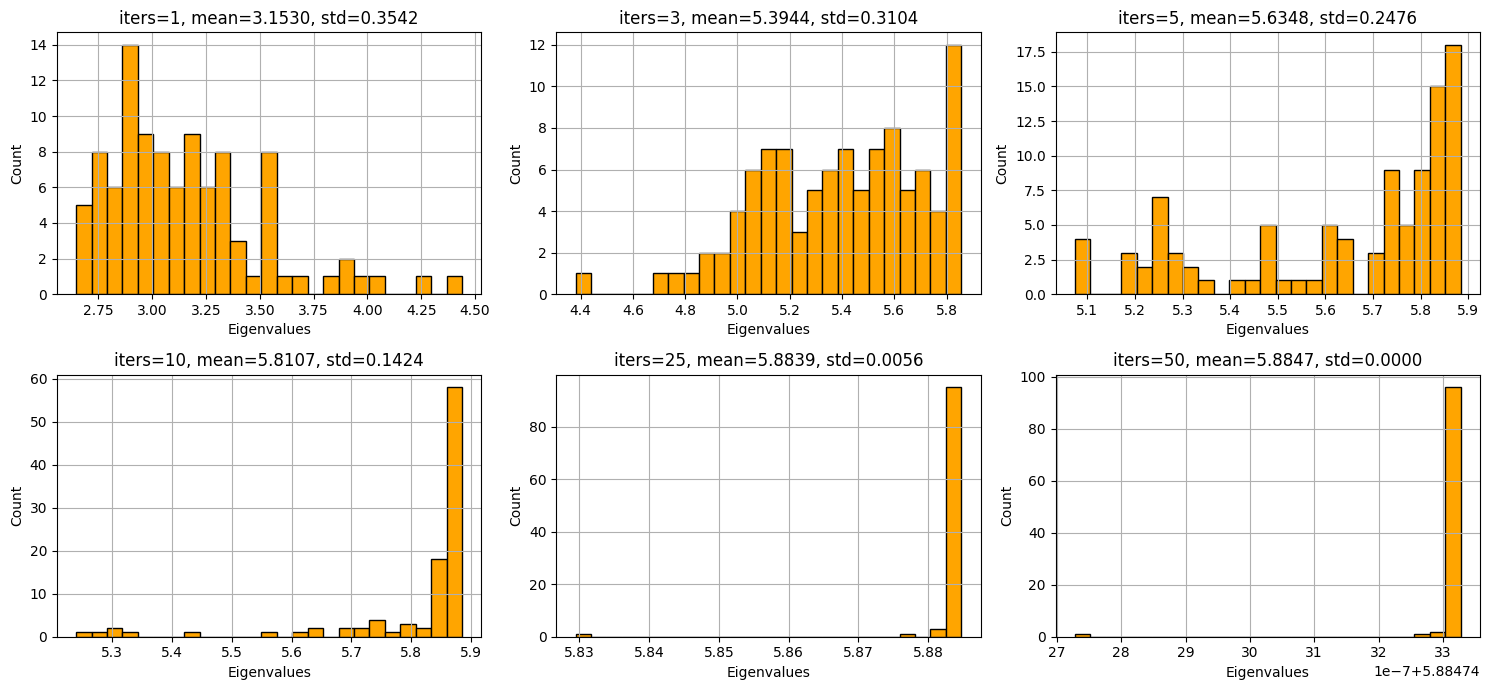

In [3]:
def plot_distribution(ax: plt.Axes, samples: List[float], title: str):
    ax.hist(samples, bins=25, color="orange", edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel("Eigenvalues")
    ax.set_ylabel("Count")
    ax.grid(True)


fig, axs = plt.subplots(2, 3, figsize=(15, 7))
axs = axs.flatten()

for i, n_iter in enumerate(n_iters):
    plot_distribution(
        axs[i],
        eigenvalues[n_iter],
        f"iters={n_iter}, mean={np.mean(eigenvalues[n_iter]):.4f}, std={np.std(eigenvalues[n_iter]):.4f}",
    )

plt.tight_layout()
plt.show()

Сходимость степенного метода - линейная с коэффициентом $\frac{\sigma_2}{\sigma_1}$: $\lim_{k \to \infty} \frac{|x_k - \sigma_1|}{|x_0 - \sigma_1|} = \left( \frac{\sigma_2}{\sigma_1} \right)^k$, где $\sigma_1$ и $\sigma_2$ - первое и второе сингулярные числа матрицы. Пусть $\frac{\sigma_2}{\sigma_1} = 0.9$, тогда для 50 итераций сходимость будет равна $0.9^{50} \approx 0.005$, - довольно точная аппроксимация.

## Задача 2. CP разложение. (10 баллов)

На лекции про тензорные разложения обсуждался метод получения CP разложения на основе попеременной минимизации невязки по каждому из факторов.

- (5 pts) Получите формулы для решения соответствующих линейных задач наименьших квадратов
- (3 pts) Реализуйте их с помощью NumPy и проверьте на случайном тензоре заданного ранга, что ваша реализация работает корректно
- (2 pts) Также покажите как зависит точность аппроксимации тензора полученного для функции $f(x) = \sin(x_1 + \ldots + x_n)$ от канонического ранга с помощью вашей функции вычисления CP- разложения.

**Bonus**: проанализируйте несколько вариантов задания порядка факторов для их обновления. Самый простой способ - последовательно обновлять факторы от 1 до $r$. Какие способы ещё возможны и почему они могут ускорить сходимость? Проверьте численно ваши гипотезы на упомянутых выше тензорах.

- CP разложение имеет вид:
    $$ x_{d_1, d_2, d_3, \ldots, d_n} = \sum_{r=1}^R a_{d_1, r}^{(1)} a_{d_2, r}^{(2)} a_{d_3, r}^{(3)}, \ldots, a_{d_n, r}^{(n)} $$
    Чтобы привести его к задаче наименьших квадратов по некоторой переменной $A^{(k)}$, развернём исходный тензор в матрицу размерности $(d_k \times \prod_{i \neq k} d_i)$, а для всех остальных матриц применим умножение `Khatri-Rao`:
    $$ C = A \odot B, A \in \mathbb{R}^{n \times m}, B \in \mathbb{R}^{k \times l} \iff c_{i, j} = a_{\lfloor i / n \rfloor, j} \cdot b_{(i \mod k), j} $$
    Тогда задача наименьших квадратов примет вид:
    $$ \min_{A^{(k)}} \left\| X - A^{(k)} \left( \bigodot_{i \neq k} A^{i} \right)^\top \right\|, X \in \mathbb{R}^{d_k \times \prod_{i \neq k} d_i} $$

In [4]:
def cp_als(tensor: np.ndarray, rank: int, n_iter: int = 1000) -> List[np.ndarray]:
    dims = tensor.shape
    arrs = [np.random.randn(dim, rank) for dim in dims]

    for _ in range(n_iter):
        for k in range(len(dims)):
            khatri_rao_ids = [i for i in range(len(dims)) if i != k]

            khatri_rao = sp.linalg.khatri_rao(
                arrs[khatri_rao_ids[0]], arrs[khatri_rao_ids[1]]
            )
            for i in range(2, len(khatri_rao_ids)):
                khatri_rao = sp.linalg.khatri_rao(khatri_rao, arrs[khatri_rao_ids[i]])

            unfolded_tensor = np.reshape(np.moveaxis(tensor, k, 0), (dims[k], -1))

            new_arr = np.linalg.lstsq(khatri_rao, unfolded_tensor.T, rcond=None)[0].T

            # Во избежание потери точности при росте номера итерации, нормируем полученный результат
            norm = np.linalg.norm(new_arr, axis=0)
            new_arr /= norm

            arrs[k] = new_arr

    # Нормируем полученные массивы, домножая их на последнюю полученную норму
    scaled_norms = norm ** (1 / len(dims))
    for i in range(len(dims)):
        arrs[i] *= scaled_norms

    return arrs

Протестируем функцию на случайном тензоре малого ранга:

In [5]:
a = np.random.randn(10, 2)
b = np.random.randn(10, 2)
c = np.random.randn(10, 2)

tensor = np.einsum("ir,jr,kr->ijk", a, b, c)

cp = cp_als(tensor, 2)

print(np.allclose(tensor, np.einsum("ir,jr,kr->ijk", *cp)))

True


Протестируем функцию на тензоре $f(x) = \sin(x_1 + \ldots + x_n)$:

In [6]:
tensor = np.sin(
    np.array([[[i + j + k for i in range(10)] for j in range(10)] for k in range(10)])
)

cp_2 = cp_als(tensor, 2)
print(
    f"Norm of error for cp rank 2: {np.linalg.norm(tensor - np.einsum('ir,jr,kr->ijk', *cp_2))}"
)

cp_3 = cp_als(tensor, 3)
print(
    f"Norm of error for cp rank 3: {np.linalg.norm(tensor - np.einsum('ir,jr,kr->ijk', *cp_3))}"
)

cp_4 = cp_als(tensor, 4)
print(
    f"Norm of error for cp rank 4: {np.linalg.norm(tensor - np.einsum('ir,jr,kr->ijk', *cp_4))}"
)

cp_5 = cp_als(tensor, 5)
print(
    f"Norm of error for cp rank 5: {np.linalg.norm(tensor - np.einsum('ir,jr,kr->ijk', *cp_5))}"
)

Norm of error for cp rank 2: 10.202822435511068
Norm of error for cp rank 3: 6.279089107070044e-14
Norm of error for cp rank 4: 2.696172659981545e-14
Norm of error for cp rank 5: 1.338225910848134e-14


Для ускорения сходимости алгоритма, можно пропускать некоторые шаги обновления факторов, если они не сильно менялись на предыдущем шаге. Модифицированный алгоритм:

In [7]:
def cp_als_optimized(
    tensor: np.ndarray,
    rank: int,
    n_iter: int = 1000,
    tol: float = 1e-8,
) -> List[np.ndarray]:
    dims = tensor.shape
    arrs = [np.random.randn(dim, rank) for dim in dims]

    skip_dims = []
    for _ in range(n_iter):
        new_skip_dims = []
        for k in range(len(dims)):
            if k in skip_dims:
                continue
            khatri_rao_ids = [i for i in range(len(dims)) if i != k]

            khatri_rao = sp.linalg.khatri_rao(
                arrs[khatri_rao_ids[0]], arrs[khatri_rao_ids[1]]
            )
            for i in range(2, len(khatri_rao_ids)):
                khatri_rao = sp.linalg.khatri_rao(khatri_rao, arrs[khatri_rao_ids[i]])

            unfolded_tensor = np.reshape(np.moveaxis(tensor, k, 0), (dims[k], -1))

            new_arr = np.linalg.lstsq(khatri_rao, unfolded_tensor.T, rcond=None)[0].T

            norm = np.linalg.norm(new_arr, axis=0)
            new_arr /= norm

            if np.linalg.norm(new_arr - arrs[k]) < tol:
                new_skip_dims.append(k)

            arrs[k] = new_arr

        skip_dims = new_skip_dims

    scaled_norms = norm ** (1 / len(dims))
    for i in range(len(dims)):
        arrs[i] *= scaled_norms

    return arrs

In [8]:
a = np.random.randn(25, 5)
b = np.random.randn(25, 5)
c = np.random.randn(25, 5)

tensor = np.einsum("ir,jr,kr->ijk", a, b, c)

print(
    f"Error of cp_als: {np.linalg.norm(tensor - np.einsum('ir,jr,kr->ijk', *cp_als(tensor, 5)))}"
)
print(
    f"Error of cp_als_optimized: {np.linalg.norm(tensor - np.einsum('ir,jr,kr->ijk', *cp_als_optimized(tensor, 5)))}"
)

print("Execution time for cp_als:")
%timeit cp_als(tensor, 5)
print("Execution time for cp_als_optimized:")
%timeit cp_als_optimized(tensor, 5)

Error of cp_als: 5.676834974711359e-13
Error of cp_als_optimized: 8.681858528911398e-13
Execution time for cp_als:
729 ms ± 66.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Execution time for cp_als_optimized:
374 ms ± 83.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Как видно из результата, новый подход действительно ускоряет сходимость алгоритма, при этом не ухудшая качество аппроксимации